DATA LOAD

In [1]:
import kagglehub
import os
path = kagglehub.dataset_download("yasserh/student-marks-dataset")
print(path)

100%|██████████| 949/949 [00:00<00:00, 793kB/s]

Extracting files...
/root/.cache/kagglehub/datasets/yasserh/student-marks-dataset/versions/1


In [7]:
import pandas as pd
import os

print(os.listdir(path))

file_path = os.path.join(path, "Student_Marks.csv")

df = pd.read_csv(file_path)

df.head()

['Student_Marks.csv']


,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


EDA

In [8]:
df.shape

(100, 3)

In [9]:
df.info

<bound method DataFrame.info of     number_courses  time_study   Marks
0                3       4.508  19.202
1                4       0.096   7.734
2                4       3.133  13.811
3                6       7.909  53.018
4                8       7.811  55.299
..             ...         ...     ...
95               6       3.561  19.128
96               3       0.301   5.609
97               4       7.163  41.444
98               7       0.309  12.027
99               3       6.335  32.357

[100 rows x 3 columns]>

NULL VALUE HANDLING

In [10]:
df.isnull().sum()

,0
number_courses,0
time_study,0
Marks,0


DUPLICATE VALUE HANDLING

In [11]:
df[df.duplicated()].shape

(0, 3)

EDA-VISUALIZATION

Bar graph between study_time vs marks

Text(0.5, 1.0, 'Study Time vs Marks')

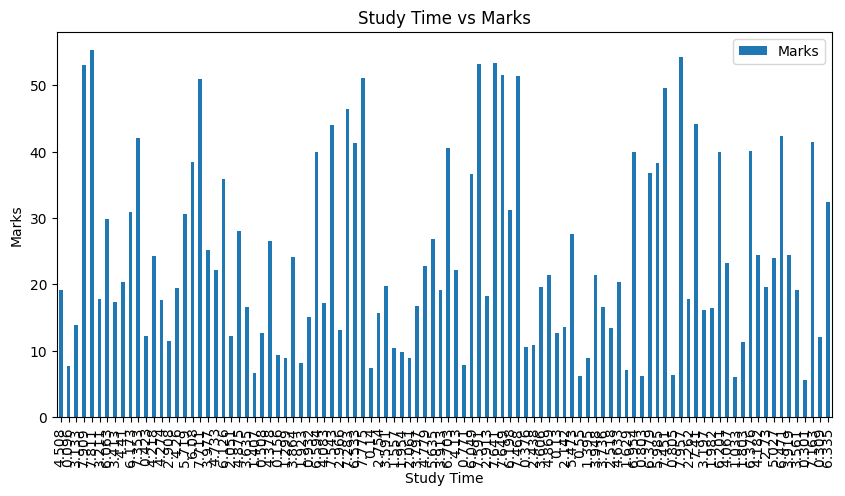

In [18]:
import matplotlib.pyplot as plt

df.plot(kind='bar', x='time_study', y='Marks',figsize=(10,5))
plt.xlabel('Study Time')
plt.ylabel('Marks')
plt.title('Study Time vs Marks')


Bar graph between number_courses vs marks

Text(0.5, 1.0, 'number_courses vs Marks')

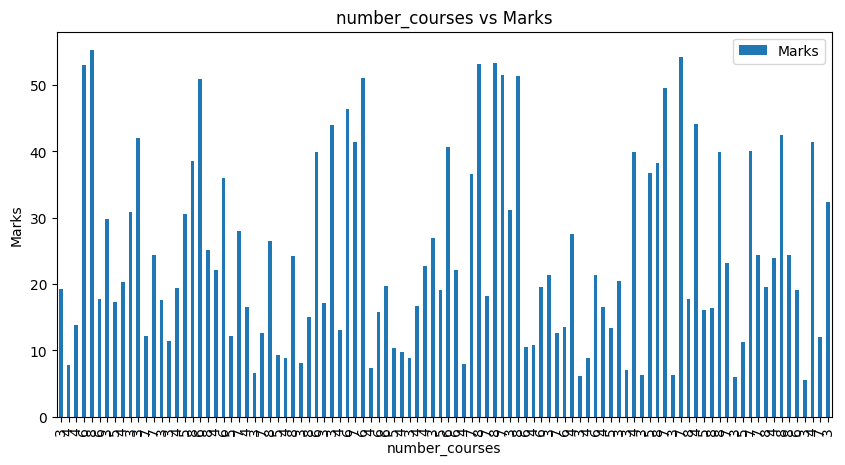

In [19]:
df.plot(kind='bar', x='number_courses', y='Marks',figsize=(10,5))
plt.xlabel('number_courses')
plt.ylabel('Marks')
plt.title('number_courses vs Marks')

SCATTER PLOT

Text(0.5, 1.0, 'number_courses vs Marks')

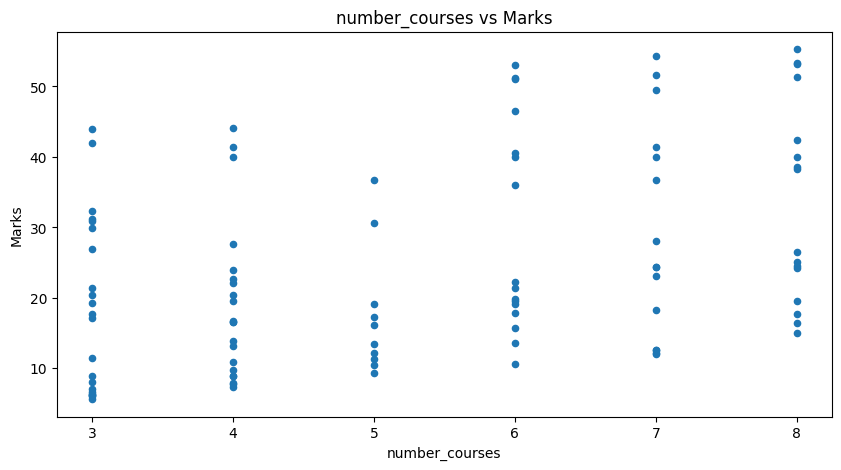

In [20]:
df.plot.scatter(x='number_courses', y='Marks',figsize=(10,5))
plt.xlabel('number_courses')
plt.ylabel('Marks')
plt.title('number_courses vs Marks')

Text(0.5, 1.0, 'time_study vs Marks')

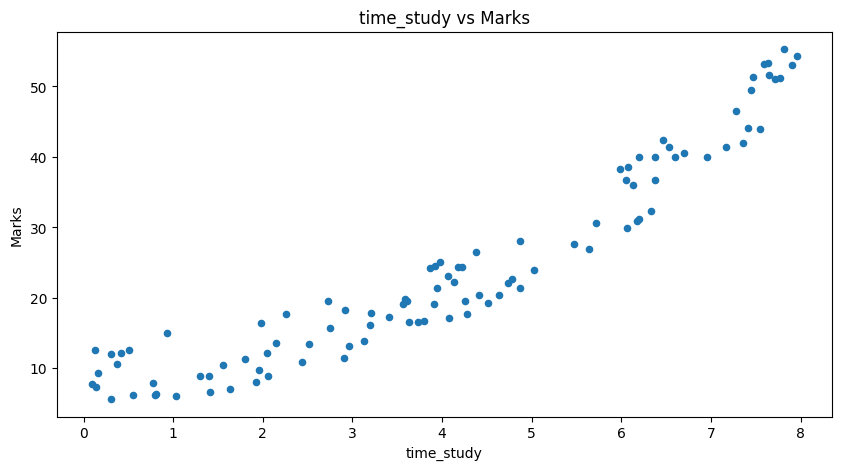

In [21]:
df.plot.scatter(x='time_study', y='Marks',figsize=(10,5))
plt.xlabel('time_study')
plt.ylabel('Marks')
plt.title('time_study vs Marks')

In [23]:
df.shape

(100, 3)

INDEPENDENT AND DEPENDENT VARIABLE

In [29]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [28]:
Y

,Marks
0,19.202
1,7.734
2,13.811
3,53.018
4,55.299
...,...
95,19.128
96,5.609
97,41.444
98,12.027


In [30]:
X

,number_courses,time_study
0,3,4.508
1,4,0.096
2,4,3.133
3,6,7.909
4,8,7.811
...,...,...
95,6,3.561
96,3,0.301
97,4,7.163
98,7,0.309


TRAIN TEST SPLIT

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1,random_state=0)

In [32]:
X_train.shape

(90, 2)

In [33]:
Y_train.shape

(90,)

In [34]:
X_test.shape

(10, 2)

In [35]:
Y_test.shape

(10,)

STANDARIZING

In [36]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

MODEL TRAIN

In [37]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,Y_train)

LinearRegression()

CROSS VALIDATION

In [38]:
import numpy as np
from sklearn.model_selection import cross_val_score
mse=cross_val_score(regression,X_train,Y_train,scoring='neg_mean_squared_error',cv=5)
mean_mse=np.mean(mse)
print(mean_mse)

-13.146148675500132


PREDICTION

In [44]:
Y_pred=regression.predict(X_test)
reg_pred

array([ 8.32284147, 27.58346417, 16.9495563 , 21.33823838,  2.48028506,
       42.45320917, 32.80425026,  6.95043801, 48.5144335 , 22.9853297 ])

GRAPH

/tmp/ipykernel_2723/4289197802.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_test-Y_pred)


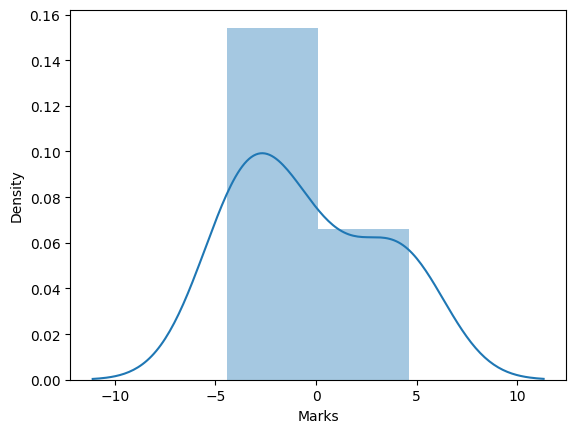

In [45]:
import seaborn as sns
sns.distplot(Y_test-Y_pred)
plt.show()

calculate r2

In [46]:
from sklearn.metrics import r2_score
score=r2_score(Y_test,Y_pred)
print(score)

0.9462669897223311


In [49]:
new_df=pd.DataFrame({'Actual':Y_test,'Predicted':Y_pred})
new_df

,Actual,Predicted
26,12.647,8.322841
86,23.149,27.583464
2,13.811,16.949556
55,18.238,21.338238
75,6.217,2.480285
93,42.426,42.453209
16,30.548,32.804250
73,7.014,6.950438
54,53.158,48.514434
95,19.128,22.985330


In [50]:
new_df['Error']=new_df['Actual']-new_df['Predicted']
new_df

,Actual,Predicted,Error
26,12.647,8.322841,4.324159
86,23.149,27.583464,-4.434464
2,13.811,16.949556,-3.138556
55,18.238,21.338238,-3.100238
75,6.217,2.480285,3.736715
93,42.426,42.453209,-0.027209
16,30.548,32.804250,-2.256250
73,7.014,6.950438,0.063562
54,53.158,48.514434,4.643566
95,19.128,22.985330,-3.857330


MEAN ABSOLUTE ERROR, MEAN SQUARED ERROR, ROOT MEAN SQUARED ERROR

In [51]:
from sklearn import metrics
print(metrics.mean_absolute_error(Y_test,Y_pred))
print(metrics.mean_squared_error(Y_test,Y_pred))
print(np.sqrt(metrics.mean_squared_error(Y_test,Y_pred)))

2.9582049931174894
11.332501955033276
3.366378165778954


GRAPH BETWEEN ACTUAL VALUE VS PREDICTED VALUE

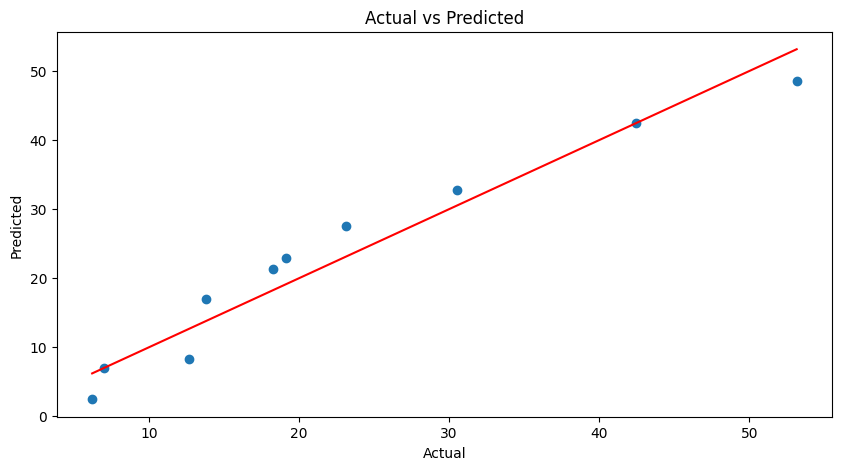

In [54]:
plt.figure(figsize=(10,5))
plt.scatter(Y_test,Y_pred)
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()],color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

NEW STUDENT PREDICTION

In [55]:
new_student=[[6,12]]
new_predict=regression.predict(new_student)
new_predict

array([198.1961007])